# Install and Import Libraries

In [1]:
!pip install pandas matplotlib numpy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the Dataset

In [3]:
#Load Dataset
path=r"C:\Users\pc\Documents\COVID_clinical_trials_Dataset.csv"
df=pd.read_csv(path)
#Show first few Rows
df.head()

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924


# Understand the Data

In [4]:
#Shape and Columns
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (5783, 27)

Columns: ['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results', 'Conditions', 'Interventions', 'Outcome Measures', 'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment', 'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date', 'Primary Completion Date', 'Completion Date', 'First Posted', 'Results First Posted', 'Last Update Posted', 'Locations', 'Study Documents', 'URL']


In [5]:
#Info about data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded Bys              

In [6]:
# Summery of missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Rank                          0
NCT Number                    0
Title                         0
Acronym                    3303
Status                        0
Study Results                 0
Conditions                    0
Interventions               886
Outcome Measures             35
Sponsor/Collaborators         0
Gender                       10
Age                           0
Phases                     2461
Enrollment                   34
Funded Bys                    0
Study Type                    0
Study Designs                35
Other IDs                     1
Start Date                   34
Primary Completion Date      36
Completion Date              36
First Posted                  0
Results First Posted       5747
Last Update Posted            0
Locations                   586
Study Documents            5601
URL                           0
dtype: int64


# Clean Important Columns

In [7]:
#Copy dataset
data = df.copy()

In [8]:
#Normalize status and phase column
data['Status'] = data['Status'].astype(str).str.strip().str.title()
if 'Phases' in data.columns:
    data['Phases'] = data['Phases'].astype(str).str.strip().str.title()


In [9]:
# Parse start date
data['Start Date'] = pd.to_datetime(data['Start Date'], errors='coerce')

In [10]:
#Convert Enrollment to numeric
data['Enrollment']=pd.to_numeric(data['Enrollment'],errors='coerce')

In [11]:
#Check cleaned summery
data.head()

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, Not Recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,COVID-IDNow,2020-11-09,"December 22, 2020","April 30, 2021","March 8, 2021",NaN,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",NaN,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not Yet Recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,COVID19-0001-USR,2020-11-02,"December 15, 2020","January 29, 2021","October 20, 2020",NaN,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",NaN,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,TAC-COVID19,2020-05-07,"June 15, 2021","June 15, 2021","May 20, 2020",NaN,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",NaN,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, Not Recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,RC-2020-08,2020-05-25,"July 31, 2020","August 31, 2020","June 4, 2020",NaN,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",NaN,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,CHRO-2020-10,2020-05-05,May 2021,May 2021,"May 20, 2020",NaN,"June 4, 2020","CHR Orléans, Orléans, France",NaN,https://ClinicalTrials.gov/show/NCT04395924


# Visualising Data

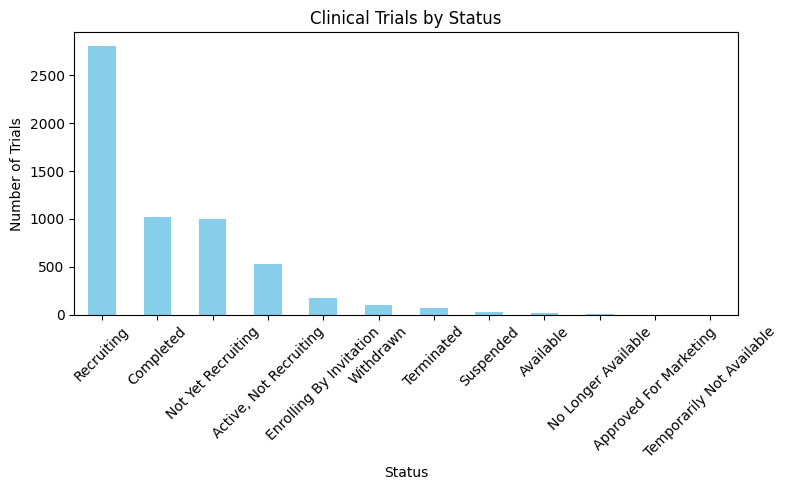

In [12]:
# Trials by Status
plt.figure(figsize=(8,5))
data['Status'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Clinical Trials by Status")
plt.xlabel("Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

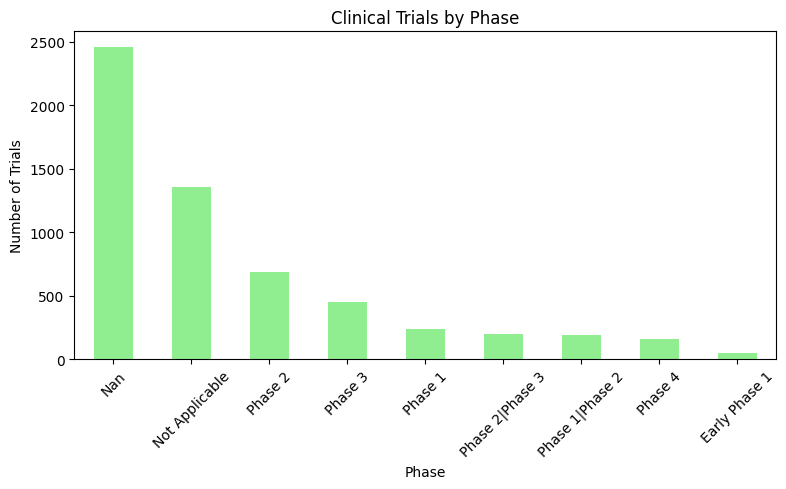

In [13]:
#Trials by Phase
if 'Phases' in data.columns:
    plt.figure(figsize=(8,5))
    data['Phases'].value_counts().plot(kind='bar', color='lightgreen')
    plt.title("Clinical Trials by Phase")
    plt.xlabel("Phase")
    plt.ylabel("Number of Trials")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

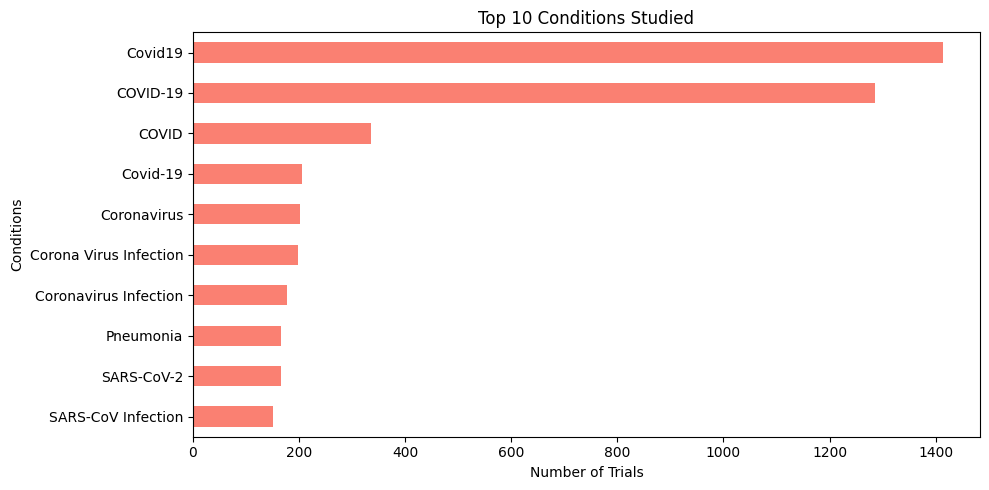

In [14]:
# Top 10 Conditions
cond_series = data['Conditions'].astype(str).str.split(r',|;|\|').explode().str.strip()
cond_series = cond_series[cond_series != '']
top_conditions = cond_series.value_counts().head(10)

plt.figure(figsize=(10,5))
top_conditions.plot(kind='barh', color='salmon')
plt.title("Top 10 Conditions Studied")
plt.xlabel("Number of Trials")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 Interventions
inter_series = data['Interventions'].astype(str).str.split(r',|;|\|').explode().str.strip()
inter_series = inter_series[inter_series != '']
top_interventions = inter_series.value_counts().head(10)

plt.figure(figsize=(10,5))
top_interventions.plot(kind='barh', color='orange')
plt.title("Top 10 Interventions Used")
plt.xlabel("Number of Trials")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

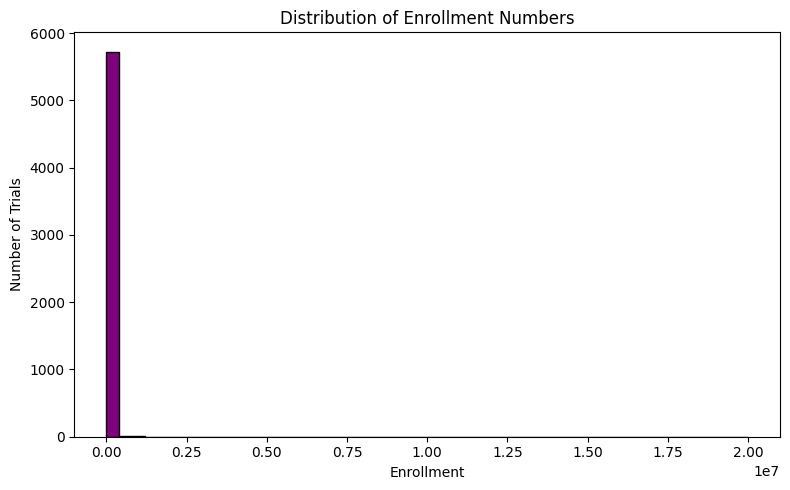

In [16]:
# Enrollment Distribution
plt.figure(figsize=(8,5))
plt.hist(data['Enrollment'].dropna(), bins=50, color='purple', edgecolor='black')
plt.title("Distribution of Enrollment Numbers")
plt.xlabel("Enrollment")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

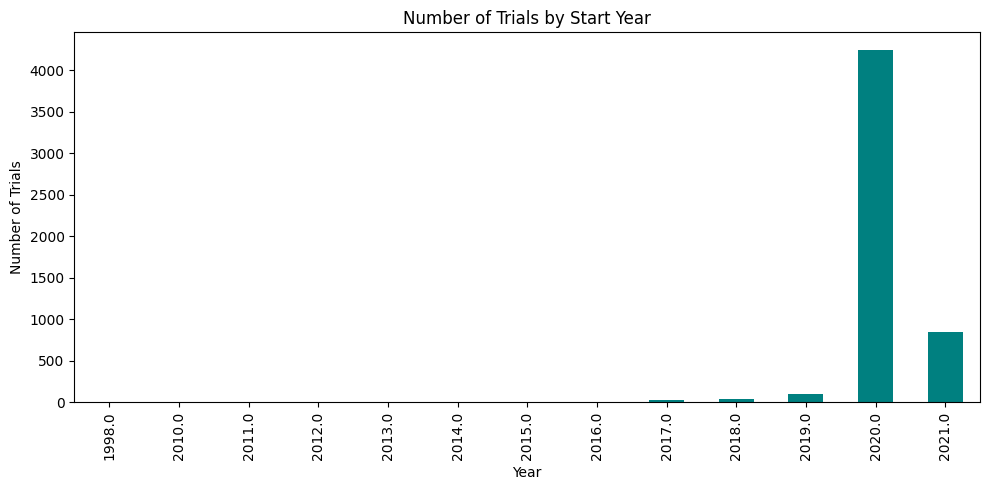

In [17]:
#Trials per Year
data['Start Year'] = data['Start Date'].dt.year
year_counts = data['Start Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
year_counts.plot(kind='bar', color='teal')
plt.title("Number of Trials by Start Year")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

# Save Cleaned Data

In [18]:
# Save Cleaned data
data.to_csv("cleaned_covid_trials_data.csv", index=False)
print("Cleaned file saved as cleaned_covid_trials_data.csv")

Cleaned file saved as cleaned_covid_trials_data.csv
